# GaSb su TEMPERATURA: FIT VARSHNI

## Importazioni

In [151]:
from qp2_subroutines import *
import os
os.getcwd() 

'/Users/zosojack/lab-ss/QP2'

In [152]:
from extracted_data.GaSb_rampa_T_peaks import GaSb_T_peaks

In [153]:
arr_T = ['78e68', '90', '100', '110', '120', '130', '140', '150', '160', '170', '180',
      '190', '200', '210', '220', '230', '240', '250', '260', '280', '300'] # + 'K'

## Preliminari

Ad alcune temperature i picchi sono tre: occorre un modo sistematico per considerare i picchi corretti. 

## PLOT DI PICCHI, FWHM E INTENSITÀ

È terribile ma almeno è super comprensibile.

In [154]:
x1, x2, x3 = [], [], []
mu1, mu2, mu3 = [], [], []
a1, a2, a3 = [], [], []
sigma1, sigma2, sigma3 = [], [], []

In [155]:
# Assemblo i vettori per il plot
for T in arr_T:
    if T == '78e68': T = '80'
    # se ce ne sono tre mu1, mu2 e mu3 sono riempiti in ordine crescente 
    if len(GaSb_T_peaks[T]) == 3:
        arr_mu = [GaSb_T_peaks[T][0][1], GaSb_T_peaks[T][1][1], GaSb_T_peaks[T][2][1]]
        arr_a = [GaSb_T_peaks[T][0][0], GaSb_T_peaks[T][1][0], GaSb_T_peaks[T][2][0]]
        arr_s = [GaSb_T_peaks[T][0][2], GaSb_T_peaks[T][1][2], GaSb_T_peaks[T][2][2]]
        i_max = np.argmax(arr_mu)
        i_min = np.argmin(arr_mu)
        i_mid = 3 - i_max - i_min

        x1.append(int(T))
        x2.append(int(T))
        x3.append(int(T))
        # - - - - - - - - - - - -
        mu1.append(GaSb_T_peaks[T][0][1]) # mu1.append(arr_mu[i_min])
        mu2.append(GaSb_T_peaks[T][1][1]) # mu2.append(arr_mu[i_mid])
        mu3.append(GaSb_T_peaks[T][2][1]) # mu3.append(arr_mu[i_max])
        # - - - - - - - - - - - -
        a1.append(GaSb_T_peaks[T][0][0]) # a1.append(arr_a[i_min])
        a2.append(GaSb_T_peaks[T][1][0]) # a2.append(arr_a[i_mid])
        a3.append(GaSb_T_peaks[T][2][0]) # a3.append(arr_a[i_max])
        # - - - - - - - - - - - -
        sigma1.append(GaSb_T_peaks[T][0][2]) # sigma1.append(arr_s[i_min])
        sigma2.append(GaSb_T_peaks[T][1][2])# sigma2.append(arr_s[i_mid])
        sigma3.append(GaSb_T_peaks[T][2][2])# sigma3.append(arr_s[i_max])
        
    elif len(GaSb_T_peaks[T]) == 2:
        if int(T) < 120:
            x1.append(int(T))
            x2.append(int(T))
            mu1.append(GaSb_T_peaks[T][0][1])
            mu2.append(GaSb_T_peaks[T][1][1])
            a1.append(GaSb_T_peaks[T][0][0])
            a2.append(GaSb_T_peaks[T][1][0])
            sigma1.append(GaSb_T_peaks[T][0][2])
            sigma2.append(GaSb_T_peaks[T][1][2])
        else: 
            x2.append(int(T))
            x3.append(int(T))
            mu2.append(GaSb_T_peaks[T][0][1])
            mu3.append(GaSb_T_peaks[T][1][1])
            a2.append(GaSb_T_peaks[T][0][0])
            a3.append(GaSb_T_peaks[T][1][0])
            sigma2.append(GaSb_T_peaks[T][0][2])
            sigma3.append(GaSb_T_peaks[T][1][2])
            
    elif len(GaSb_T_peaks[T]) == 1:
        x2.append(int(T))
        mu2.append(GaSb_T_peaks[T][0][1])
        a2.append(GaSb_T_peaks[T][0][0])
        sigma2.append(GaSb_T_peaks[T][0][2])

    else:
        raise KeyError ('È andato storto qualcosa nella costruzione di GaSb_T_peaks')

## $\mu$ su T + Varshni

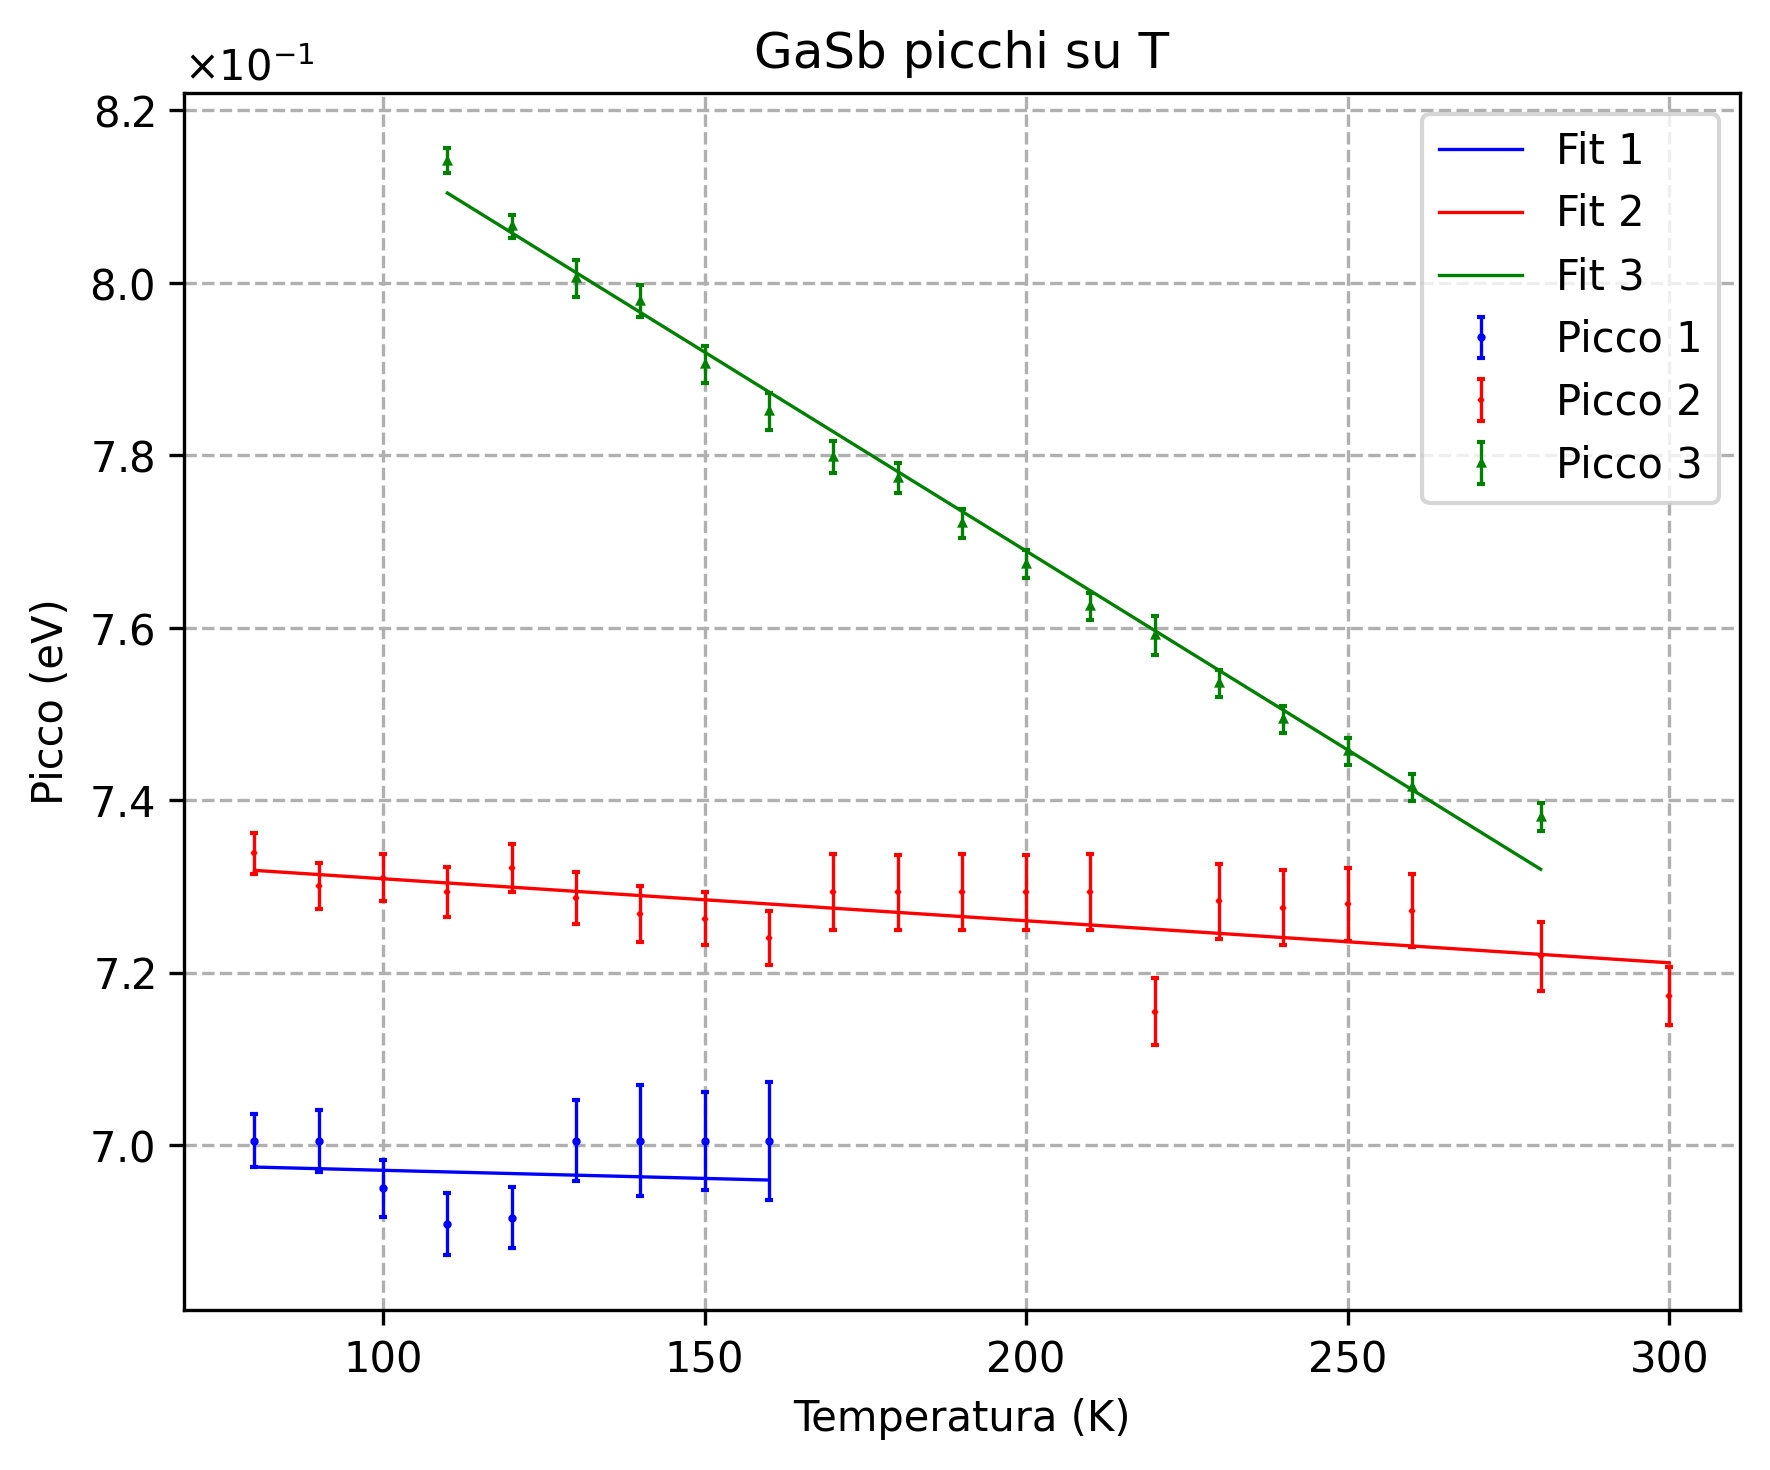

• Varshni 1
 - $E_0$ = 0.6989546225861674
 - $\alpha$ = 1.882890771171292e-05
 - $\beta$ = -0.009370206374804999
 - chi2rid = 1.5547793786697166
• Varshni 2
 - $E_0$ = 0.7357545162182476
 - $\alpha$ = 4.873128196769534e-05
 - $\beta$ = 0.0027517980112724133
 - chi2rid = 0.9541627963901664
• Varshni 3
 - $E_0$ = 0.8611482084550574
 - $\alpha$ = 0.00046130320110622275
 - $\beta$ = 0.00041641466744276635
 - chi2rid = 2.197379490342454


In [156]:
## PLOT ##

plt.figure(figsize=(6,5), dpi=300)
# serve errorbar 
#err_mu = 1.4145357031249999
x1, x2, x3 = np.array(x1), np.array(x2), np.array(x3)
mu1, mu2, mu3 = np.array(mu1), np.array(mu2), np.array(mu3)
err1, err2, err3 = np.array(sigma1)/10, np.array(sigma2)/10, np.array(sigma3)/10

plt.errorbar(x1, mu1, yerr=err1, linestyle='-', marker='o', markersize=1, elinewidth=0.8, capsize=1,
             color='b', label='Picco 1', linewidth=0.)
plt.errorbar(x2, mu2, yerr=err2, linestyle='-', marker='x', markersize=1, elinewidth=0.8, capsize=1,
             color='r', label='Picco 2', linewidth=0.)
plt.errorbar(x3, mu3, yerr=err3, linestyle='-', marker='^', markersize=1, elinewidth=0.8, capsize=1,
             color='g', label='Picco 3', linewidth=0.)

## VARSHNI ##
p0 = [0.7, 0.1, 0.1]
low = [-np.inf, -np.inf, -np.inf]
upp = [np.inf, np.inf, np.inf]
popt1, pcov1 = curve_fit(varshni, x1, mu1, sigma=err1, p0=p0, bounds=(low,upp))
popt2, pcov2 = curve_fit(varshni, x2, mu2, sigma=err2, p0=p0, bounds=(low,upp))
popt3, pcov3 = curve_fit(varshni, x3, mu3, sigma=err3, p0=p0, bounds=(low,upp))

## PLOT CURVA FIT ##
x_plot1 = np.linspace(x1[0], x1[-1],int(x1[-1]-x1[0]))
y_plot1 = varshni(x_plot1, *popt1)
plt.plot(x_plot1, y_plot1, linestyle='-', color='b', label=f"Fit 1", linewidth=0.8)#, zorder=2)
x_plot2 = np.linspace(x2[0], x2[-1],int(x2[-1]-x2[0]))
y_plot2 = varshni(x_plot2, *popt2)
plt.plot(x_plot2, y_plot2, linestyle='-', color='r', label=f"Fit 2", linewidth=0.8)#, zorder=2)
x_plot3 = np.linspace(x3[0], x3[-1],int(x3[-1]-x3[0]))
y_plot3 = varshni(x_plot3, *popt3)
plt.plot(x_plot3, y_plot3, linestyle='-', color='g', label=f"Fit 3", linewidth=0.8)#, zorder=2)

## OPZIONI GRAFICHE ##
plt.title(r'GaSb picchi su T')
plt.xlabel("Temperatura (K)")
plt.ylabel("Picco (eV)")
plt.ticklabel_format(axis='y', useMathText=True, scilimits=(0,0) ) #style='scientific'
plt.legend()
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()

## CHI2 ##
chi2_1, dof_1 = chi2_varshni (x1, mu1, err_y=err1, popt=popt1)
chi2_2, dof_2 = chi2_varshni (x2, mu2, err_y=err2, popt=popt2)
chi2_3, dof_3 = chi2_varshni (x3, mu3, err_y=err3, popt=popt3)

## PRINT RISULTATI FIT ##
print('• Varshni 1')
print(r' - $E_0$ =', popt1[0])
print(r' - $\alpha$ =', popt1[1])
print(r' - $\beta$ =', popt1[2])
print(' - chi2rid =', chi2_1/dof_1)
print('• Varshni 2')
print(r' - $E_0$ =', popt2[0])
print(r' - $\alpha$ =', popt2[1])
print(r' - $\beta$ =', popt2[2])
print(' - chi2rid =', chi2_2/dof_2)
print('• Varshni 3')
print(r' - $E_0$ =', popt3[0])
print(r' - $\alpha$ =', popt3[1])
print(r' - $\beta$ =', popt3[2])
print(' - chi2rid =', chi2_3/dof_3)

## FWHM su T

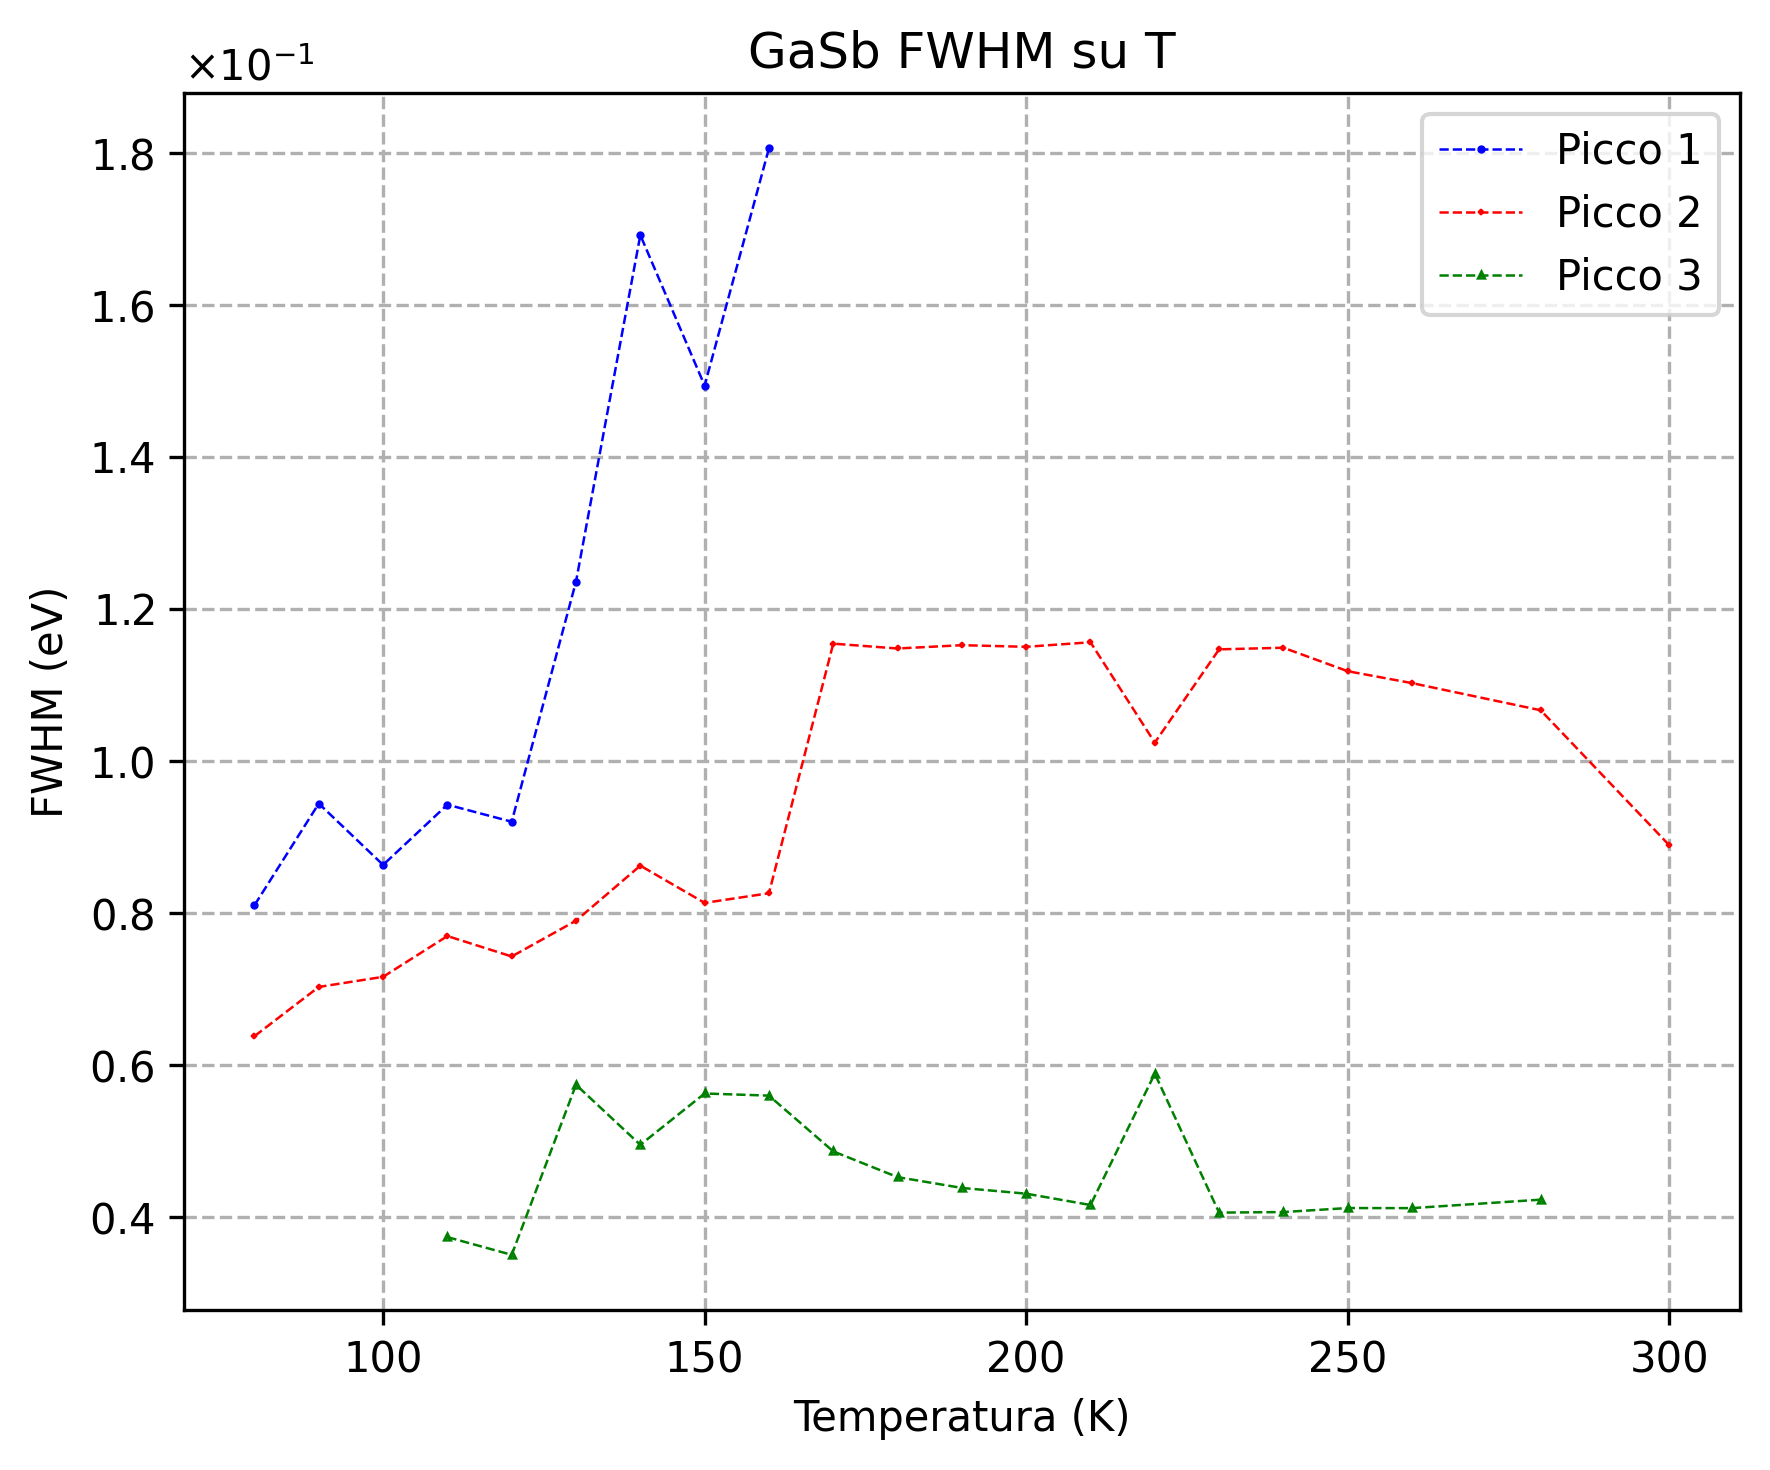

In [157]:
## PLOT ##

plt.figure(figsize=(6,5), dpi=300)
# serve errorbar 
err_mu = 1.4145357031249999

fwhm1 = 2.633 * np.array(sigma1)
fwhm2 = 2.633 * np.array(sigma2)
fwhm3 = 2.633 * np.array(sigma3)

plt.errorbar(x1, fwhm1, linestyle='--', marker='o', markersize=1, elinewidth=0.8, capsize=1,
             color='b', label='Picco 1', linewidth=0.6)
plt.errorbar(x2, fwhm2, linestyle='--', marker='x', markersize=1, elinewidth=0.8, capsize=1,
             color='r', label='Picco 2', linewidth=0.6)
plt.errorbar(x3, fwhm3, linestyle='--', marker='^', markersize=1, elinewidth=0.8, capsize=1,
             color='g', label='Picco 3', linewidth=0.6)

## OPZIONI GRAFICHE ##
plt.title(r'GaSb FWHM su T')
plt.xlabel("Temperatura (K)")
plt.ylabel("FWHM (eV)")
plt.ticklabel_format(axis='y',style='scientific', useMathText=True, scilimits=(0,0) )
plt.legend()
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()

## Intensità integrata su T

height ∗ sigma ∗ 2 π

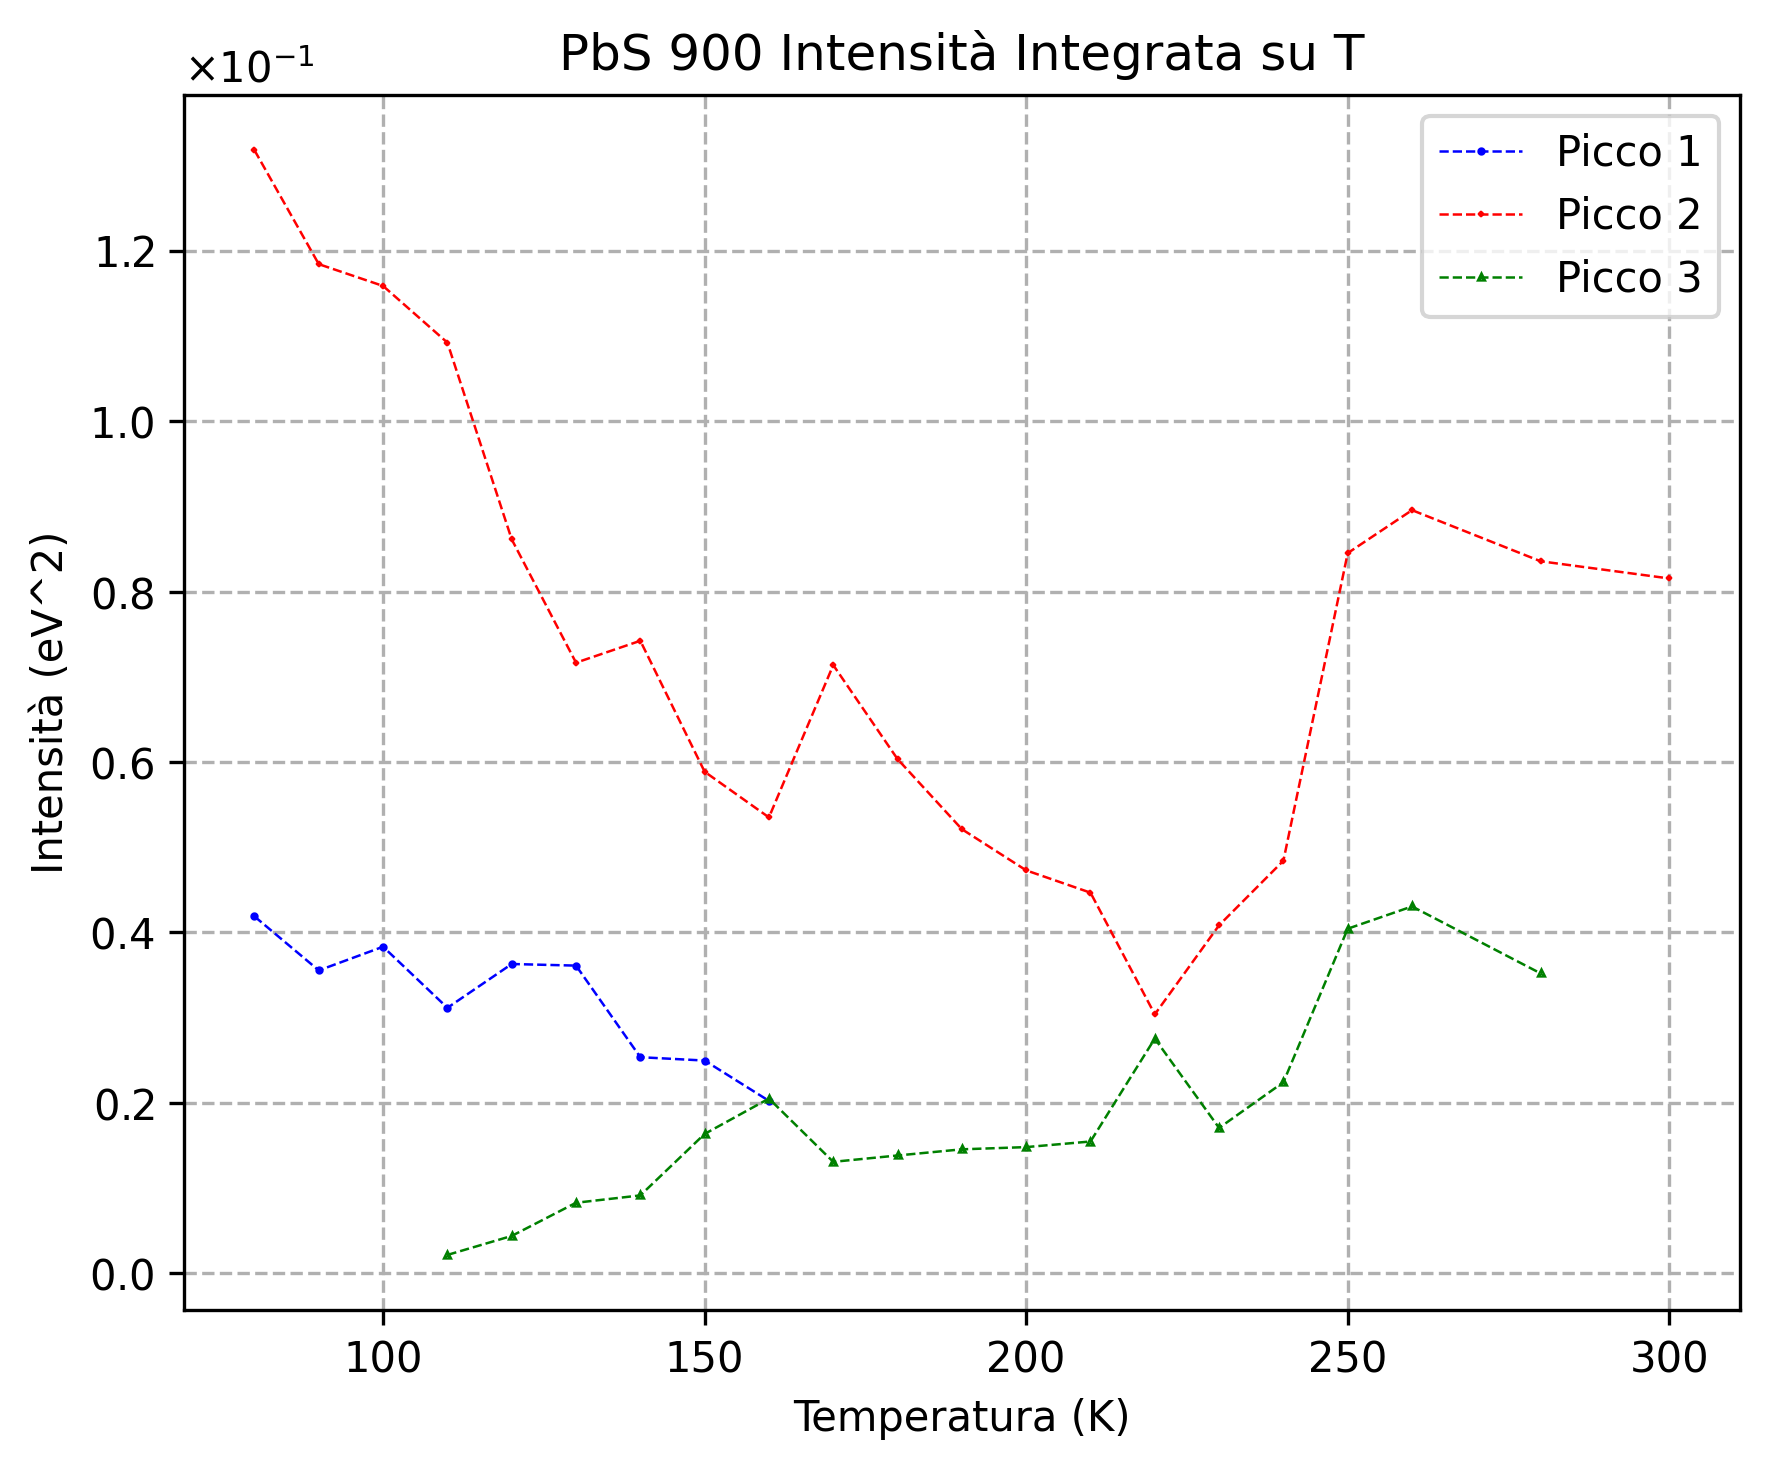

In [158]:
## PLOT ##

plt.figure(figsize=(6,5), dpi=300)

intensità1 = np.array(a1) * np.array(sigma1) * 2 * np.pi
intensità2 = np.array(a2) * np.array(sigma2) * 2 * np.pi
intensità3 = np.array(a3) * np.array(sigma3) * 2 * np.pi

plt.errorbar(x1, intensità1, linestyle='--', marker='o', markersize=1, elinewidth=0.8, capsize=1,
             color='b', label='Picco 1', linewidth=0.6)
plt.errorbar(x2, intensità2, linestyle='--', marker='x', markersize=1, elinewidth=0.8, capsize=1,
             color='r', label='Picco 2', linewidth=0.6)
plt.errorbar(x3, intensità3, linestyle='--', marker='^', markersize=1, elinewidth=0.8, capsize=1,
             color='g', label='Picco 3', linewidth=0.6)

## OPZIONI GRAFICHE ##
plt.title(r'PbS 900 Intensità Integrata su T')
plt.xlabel("Temperatura (K)")
plt.ylabel("Intensità (eV^2)")
plt.ticklabel_format(axis='y',style='scientific', useMathText=True, scilimits=(0,0) )
plt.legend()
plt.grid(linestyle='--')
plt.tight_layout()
plt.show()